In [1]:
import numpy as np
import cv2
import time
import os
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
img = Image.open(r'C:\Users\hp\Desktop\linegrid\annotations\119.png')
img = np.array(img)

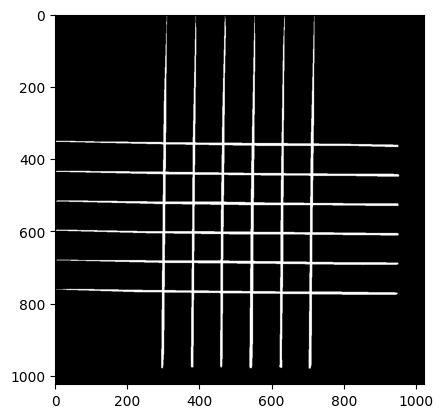

In [3]:
binary_map = np.zeros_like(img, dtype=np.uint8)
binary_map[img == 1] = 255
plt.imshow(binary_map, cmap='gray')

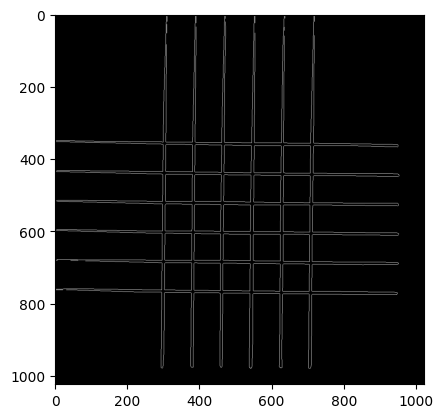

In [8]:
# img2 = cv2.Laplacian(binary_map, -1)
img2 = cv2.Canny(binary_map, 100, 200)
plt.imshow(img2, cmap='gray')
plt.show()

In [10]:
#找轮廓并发现最大轮廓
contours, hierarchy	= cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
# contours, hierarchy	= cv2.findContours(img2, cv2.RETR_FLOODFILL, cv2.CHAIN_APPROX_NONE)

# contours = np.array(contours, dtype=object) #轮廓的长度不一样，无法表示为一个固定大小的numpy数组
contours_size = np.array([cv2.contourArea(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[0] #取一个轮廓，按t增加索引

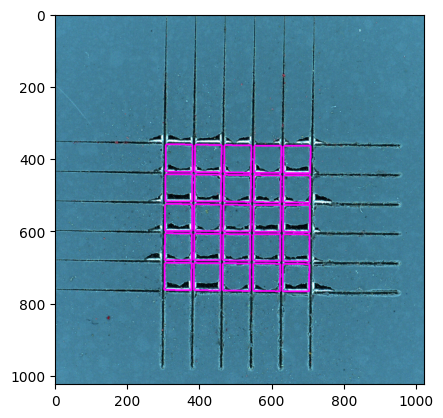

In [11]:
_src_path = r'C:\Users\hp\Desktop\linegrid\119.jpg'

src_img = cv2.imread(_src_path)
contour = contours[sort_index[25]]
# poly = cv2.approxPolyDP(contour, 1, True) #多边形拟合
for _i in range(0, 25):
    contour = contours[sort_index[_i]]
    cv2.drawContours(src_img, [contour], 0, (255,0,255), thickness=3) #画原轮廓
# cv2.drawContours(src_img, [contour], 0, (255,0,255), thickness=3) 
plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))

In [7]:
def drawRotateRectCV( img, rotateRect, color = (0,122,255), thickness= 5):
    points = cv2.boxPoints(rotateRect)
    for i in range(0,4):
        cv2.line(img, [int(points[i][0]), int(points[i][1])], [int(points[(i+1)%4][0]), int(points[(i+1)%4][1])], 
                    color, thickness=thickness)